# Rice Leaf Disease Classification

In [1]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_path = 'plant_small.zip'
extract_path = '.'

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Preparing Dataset

In [2]:
from tensorflow import keras

# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = 'plant_small/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (128,128),
    color_mode='rgb',
    shuffle=True
)


val_ds = keras.utils.image_dataset_from_directory(
    directory = 'plant_small/val',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (128,128),
    color_mode='rgb',
    shuffle=True
)

Found 2378 files belonging to 6 classes.
Found 499 files belonging to 6 classes.


In [3]:
print(train_ds.class_names)

['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


# Image Visualization

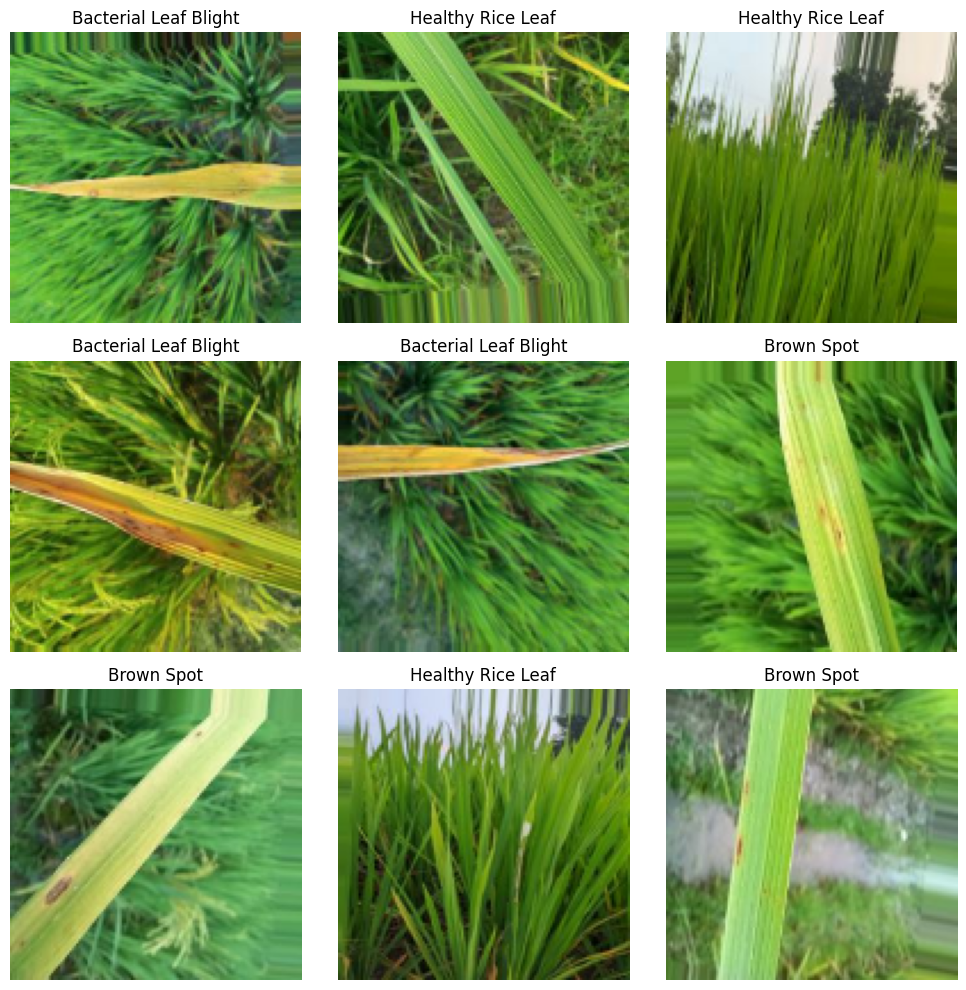

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names
class_names = train_ds.class_names

# Extract one batch from the dataset
for images, labels in train_ds.take(1):
    images = images.numpy().astype("uint8")
    labels = labels.numpy()

    # Set up subplot grid
    plt.figure(figsize=(10, 10))

    for i in range(9):  # First 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Model Building

In [5]:
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Input, Dropout, RandomFlip, RandomRotation, RandomZoom, Rescaling

# Data Augmentation Layer
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

model = Sequential()
model.add(Input(shape=(128,128,3)))
model.add(Rescaling(1./255)) # Ensure normalization
model.add(data_augmentation)

model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',padding="same",))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3),activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, kernel_size=(3, 3),activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, kernel_size=(3, 3),activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))

In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,618,566 (17.62 MB)

 Trainable params: 4,617,606 (17.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



# Model Training

In [ ]:
epochs=20
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Epoch 1/20
20/75 ━━━━━━━━━━━━━━━━━━━━ 3:14 4s/step - accuracy: 0.2944 - loss: 1.7595

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {val_accuracy:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get class names
class_names = val_ds.class_names

# Step 1: Collect true and predicted labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)  # get class with highest probability

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# Step 2: Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# Step 3: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by true labels

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Accuracy %)")
plt.tight_layout()
plt.show()

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

# Prediction function
def predict(image):
    # Resize and normalize image
    img = tf.image.resize(image, (128, 128))  # match model input size
    img = tf.expand_dims(img, axis=0)         # add batch dimension


    # Predict
    pred = model.predict(img)
    class_idx = np.argmax(pred[0])
    class_name = class_names[class_idx]
    confidence = float(pred[0][class_idx])

    return {class_name: confidence}

# Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    title="Rice Leaf Disease Classifier",
    description="Upload a rice leaf image to classify the disease."
)

# Launch the app
interface.launch()

# Export Model for Deployment

In [ ]:
# 1. Save as Keras format (Standard for FastAPI backend)
model.save('rice_disease_model.keras')
print("Model saved as rice_disease_model.keras")

# 2. Export to TFLite (Optimized for edge/mobile)
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('rice_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model exported as rice_disease_model.tflite")

# 3. Save Class Names
import json
with open('class_names.json', 'w') as f:
    json.dump(train_ds.class_names, f)
print("Class names saved as class_names.json")